# Clase: Forecasting Automatizado de Series de Tiempo con Python

**Duración:** 1 hora 40 minutos
**Curso:** Análisis de Datos Financieros y Diseño de Indicadores
**Caso práctico:** RazerTech Inc. – Predicción de ventas mensuales

---

## 1. Introducción y contexto (10 min)

### ¿Por qué automatizar el pronóstico de series de tiempo?

* Ventajas en la toma de decisiones (inventario, marketing, producción).
* Dificultades de modelos clásicos (ARIMA, SARIMA, etc) vs herramientas AutoML y automatización.

### Contexto del caso

RazerTech Inc. fabrica y vende electrónicos; ventas mensuales volátiles por estacionalidad y tendencias. El reto es prever las ventas mensuales del siguiente año para mejorar decisiones de inventario y marketing.

---

## 2. Panorama de librería elegida: **Darts** (15 min)

### ¿Por qué Darts?

* **Darts** ha recibido los mejores comentarios en la comunidad por su sencillez, potencia y versatilidad.
* Permite usar desde modelos clásicos (ARIMA, Exp. Smoothing) hasta redes neuronales modernas, todo bajo una API similar a scikit-learn (`fit()`/`predict()`).
* Soporta series multivariadas, covariables, backtesting y pipelines.
* Fuerte documentación y comunidad activa ([Darts GitHub](https://github.com/unit8co/darts)).

### Pros (según la comunidad)

* Fácil de instalar y usar.
* Permite comparar múltiples modelos con muy poco código.
* Soporte de forecasting probabilístico, deep learning, y datos faltantes.

### Contras (según la comunidad)

* Dependencias (Torch para modelos DL, pero puedes usar solo modelos clásicos si prefieres).
* Errores menores al usar covariables estáticas (evitables en este caso simple).


---

## 3. Caso Práctico: RazerTech Inc. (Método del Caso) (60 min)

### Objetivo

* Prever ventas mensuales del siguiente año con modelos automáticos de Darts.
* Entregar recomendaciones basadas en el análisis.

---

### 3.1. **Preparación de datos** (10 min)

* Graficar las ventas para identificar tendencias y estacionalidad.


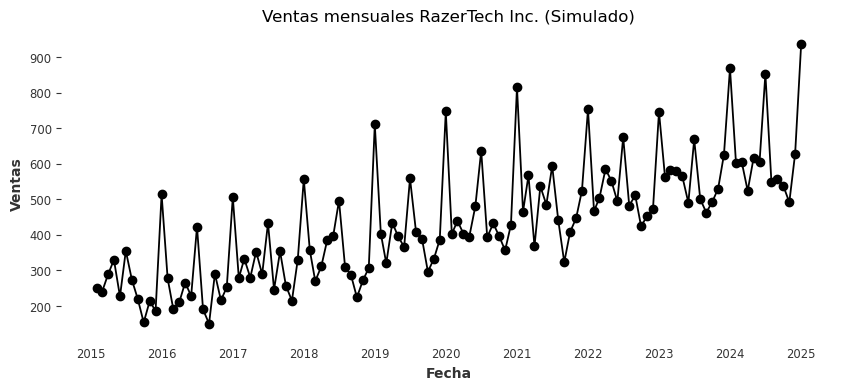

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df_ventas = pd.read_csv('data/ventas_mensuales.csv', parse_dates=['Fecha']).rename({'Fecha':'fecha', 'Ventas':'ventas'}, axis=1)
df_ventas.head()

# Graficar
plt.figure(figsize=(10,4))
plt.plot(df_ventas['fecha'], df_ventas['ventas'], marker='o')
plt.title('Ventas mensuales RazerTech Inc. (Simulado)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid()
plt.show()

---

### 3.2. **Primer pronóstico automático con Darts** (15 min)

#### Instalación

In [11]:
!pip install darts --quiet

#### Pipeline con modelo automático (Ejemplo: ExponentialSmoothing y AutoARIMA)

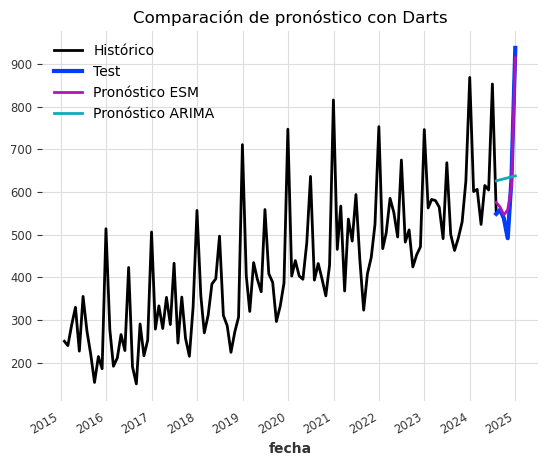

In [12]:
from darts import TimeSeries
from darts.models import ExponentialSmoothing, AutoARIMA
from darts.metrics import mae, rmse

# Convertir DataFrame a TimeSeries
serie = TimeSeries.from_dataframe(df_ventas, 'fecha', 'ventas')

# Separar en train/test (últimos 6 meses para test)
train, test = serie[:-6], serie[-6:]

# Entrenar modelos
modelo_esm = ExponentialSmoothing()
modelo_esm.fit(train)
forecast_esm = modelo_esm.predict(len(test))

modelo_arima = AutoARIMA()
modelo_arima.fit(train)
forecast_arima = modelo_arima.predict(len(test))

# Graficar
serie.plot(label='Histórico')
test.plot(label='Test', lw=3)
forecast_esm.plot(label='Pronóstico ESM')
forecast_arima.plot(label='Pronóstico ARIMA')
plt.title('Comparación de pronóstico con Darts')
plt.legend()
plt.show()

---

### 3.3. **Evaluación de modelos y pronóstico futuro** (15 min)

#### Medir el error sobre el periodo de test:

In [13]:
print('Exponential Smoothing - MAE:', mae(test, forecast_esm))
print('Auto ARIMA - MAE:', mae(test, forecast_arima))

Exponential Smoothing - MAE: 24.45233917919299
Auto ARIMA - MAE: 114.67277017914803


#### Pronóstico para los próximos 12 meses:

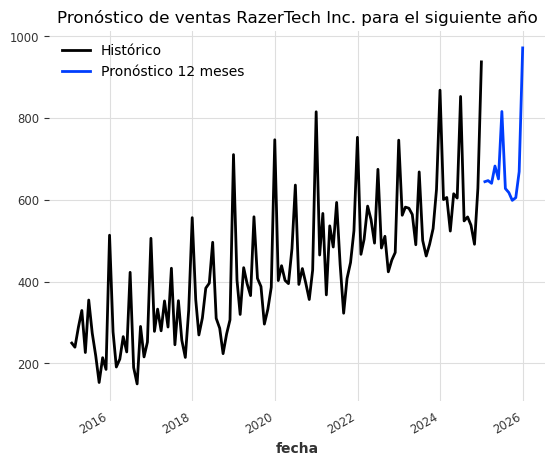

In [15]:
if mae(test, forecast_arima) < mae(test, forecast_esm):    
    modelo_final = modelo_arima.fit(serie)
else:
    modelo_final = modelo_esm.fit(serie)

forecast_next = modelo_final.predict(12)

serie.plot(label='Histórico')
forecast_next.plot(label='Pronóstico 12 meses')
plt.title('Pronóstico de ventas RazerTech Inc. para el siguiente año')
plt.legend()
plt.show()

---

### 3.4. **Recomendaciones para la empresa (10 min)**

* Analiza visualmente si hay estacionalidad/tendencia.
* Si la predicción sugiere alzas: sugerir aumentar inventario o campañas de marketing.
* Si hay baja: estrategias de liquidación o ajuste de producción.
* Subrayar la importancia de seguir monitoreando y reentrenar cada trimestre.

---

## 4. Discusión crítica y cierre (15 min)

* ¿Qué tan confiable es el modelo automático?
* ¿Qué errores/alertas se presentaron?
* ¿Cómo se compara la automatización contra modelos manuales?
* Debate: ¿en qué escenarios conviene usar AutoML y cuándo es preferible el análisis tradicional?

---

## 5. Recursos y referencias

* [Documentación Darts](https://github.com/unit8co/darts)
* [Ejemplos de la comunidad y reportes de errores](https://github.com/unit8co/darts/issues)
* [Comparativas y opiniones en Reddit](https://www.reddit.com/r/MachineLearning/comments/1bho0r0/in_2024_which_library_is_best_for_time_series/)
* [Introducción AutoML para series de tiempo (arXiv)](https://arxiv.org/abs/2110.03224)